# 0. このノートブックに関して

このノートブックでは因果モデルのモデル化に正規化フローを用いた場合の学習性能を以下の二つのケースで分析することを目標とする。

・因果グラフ既知の元でメカニズムを正規化フローでモデル化し学習し誤差や尤度などから性能を評価

・因果グラフ未知のもとでNOTEARSと組み合わせて因果探索から行い、正規化フローと合わせて学習した場合にどのような性能が出るかを検証


# 1. Causal Normalizing Flowsの実装

## 1.1 シミュレーションデータとデータローダの実装

In [1]:
from notears.utils import simulate_dag, simulate_parameter, simulate_linear_sem
import numpy as np


n, d, s0, graph_type, sem_type = 100, 20, 20, 'ER', 'gauss'
B_true = simulate_dag(d, s0, graph_type)
W = simulate_parameter(B_true)
X = simulate_linear_sem(W, n, sem_type)

X.shape

(100, 20)

In [2]:
import torch
from torch.utils.data import Dataset


class CustomSyntheticDataset(Dataset):
    def __init__(self, X, device='cpu'):
        self.device = device
        self.x = torch.from_numpy(X).to(device)
        self.len = self.x.shape[0]
        self.data_dim = self.x.shape[1]
        
    def __len__(self):
        return self.len
    
    def __getitem__(self, idx):
        return self.x[idx]
    
    def get_metadata(self):
        return {
            'n': self.len,
            'data_dim': self.data_dim,
        }

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dset = CustomSyntheticDataset(X.astype(np.float32), device)
train_loader = DataLoader(dset, shuffle=True, batch_size=10)
for _, x in enumerate(train_loader):
    x = x.to(device)
    print(x.shape)

torch.Size([10, 20])
torch.Size([10, 20])
torch.Size([10, 20])
torch.Size([10, 20])
torch.Size([10, 20])
torch.Size([10, 20])
torch.Size([10, 20])
torch.Size([10, 20])
torch.Size([10, 20])
torch.Size([10, 20])


## 1.2 訓練過程の実装（暫定）

In [ ]:
# トポロジカルオーダに沿った自己回帰フローを取得する

import igraph as ig
from torch.distributions import MultivariateNormal, Laplace
from nflib import DAGAffineCL, NormalizingFlowModel, MLP1Layer, MLP4, PosEncMLP, MAF, NSF_AR

def _get_flow_arch(self, B):
    
    dim = self.dim
    
    # prior distribution type
    if self.config.flow.prior_dist == 'gauss':
        prior = MultivariateNormal(torch.zeros(dim).to(device), torch.eye(dim).to(device))
    elif self.config.flow.prior_dist == 'laplace':
        prior = Laplace(torch.zeros(dim).to(device), torch.ones(dim).to(device))
    else:
        raise ValueError(f'Invalid prior distribution: {self.config.flow.prior_dist}')
    
    # net type for flow parameters
    if self.config.flow.net_type == 'mlp':
        net_class = MLP1Layer
    elif self.config.flow.net_type == 'mlp4':
        net_class = MLP4
    elif self.config.flow.net_type == 'posencmlp':
        net_class = PosEncMLP
    else:
        raise NotImplementedError(f'Invalid net type: {self.config.flow.net_type}')
    
    """
    # flow type
    if self.config.flow.architecture == 'realnvp':
        ar_flow = AffineCL(dim=dim, ..)
    elif self.config.flow.architecture == 'maf':
        ar_flow = MAF(dim=dim, ..)
    elif self.config.flow.architecture == 'spline':
        ar_flow = NSF_AR(dim=dim, ..)
    else:
        raise NotImplementedError(f'Invalid flow architecture: {self.config.flow.architecture}')
    """

    # get flow architecture
    G = ig.Graph.Adjacency(B.tolist(), mode='directed')
    ordered_vertices = G.topological_sorting()
    flow_list = []
    for vertex in ordered_vertices:
        cond_idx = G.neighbors(vertex, mode=ig.IN)
        ar_flow = DAGAffineCL(dim=dim, cond_idx=cond_idx, trans_idx=[vertex], ..)
        flow_list.append(ar_flow)
    
    flow = NormalizingFlowModel(prior, flow_list).to(device)
    return flow

In [4]:
import igraph as ig
import numpy as np

B = np.array([
        [0, 1, 1],  # ノード0 → ノード1, 2
        [0, 0, 1],  # ノード1 → ノード2  
        [0, 0, 0]   # ノード2は子なし
    ])

G = ig.Graph.Adjacency(B.tolist(), mode='directed')
ordered_vertices = G.topological_sorting()

for  i, vertex in enumerate(ordered_vertices):
    print(G.neighbors(vertex, mode=ig.IN))
    print(vertex)

[]
0
[0]
1
[0, 1]
2


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim



def _get_optimizer(self, parameters):
    """
    Returns an optimizer according to the config file
    """
    optimizer = optim.Adam(parameters, lr=self.config.optim.lr, weight_decay=self.config.optim.weight_decay,
                            betas=(self.config.optim.beta1, 0.999), amsgrad=self.config.optim.amsgrad)
    if self.config.optim.scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=3, verbose=self.verbose)
    else:
        scheduler = None
    return optimizer, scheduler

In [ ]:
# 訓練過程


import torch
from torch.utils.data import DataLoader

def _train(self, dset, B):
    
    train_loader = DataLoader(dset, shuffle=True, batch_size=self.config.training.batch_size)
    flow = self._get_flow_arch(B)
    
    optimizer, scheduler = self._get_optimizer(flow.parameters())
    flow.train()
    loss_vals = []
    for e in range(self.epochs):
        loss_val = 0
        for _, x in enumerate(train_loader):
            x = x.to(device)
            _, prior_logprob, log_det = flow(x)
            loss = - torch.sum(prior_logprob + log_det)
            loss_val += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if self.config.optim.scheduler:
            scheduler.step(loss_val / len(train_loader))
        if self.verbose:
            print('epoch {}/{} \tloss: {}'.format(e, self.epochs, loss_val))
        loss_vals.append(loss_val)
    
    return flow, loss_vals


## 1.3 Normalizing Flowの実装

In [62]:
import torch
import torch.nn as nn

class MLP4(nn.Module):
    """ a simple 4-layer MLP """

    def __init__(self, nin, nout, nh):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nin, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nout),
        )

    def forward(self, x):
        return self.net(x)

In [63]:
# DAGに基づいてマスクを行うAffineCLの実装


import torch
import torch.nn as nn
#from nflib import MLP4

class DAGAffineCL(nn.Module):
    
    def __init__(self, dim, cond_idx, trans_idx, net_class=MLP4, nh=24, scale_shift_base=False):
        super().__init__()
        self.dim = dim
        self.cond_idx = cond_idx
        self.trans_idx = trans_idx
        # self.id_idx = [i for i in range(dim) if i not in self.trans_idx]  # unchanged part
        
        in_dim = len(self.cond_idx)
        out_dim = len(self.trans_idx)
        
        if len(self.cond_idx) > 0:
            self.s_cond = net_class(in_dim, out_dim, nh)
            self.t_cond = net_class(in_dim, out_dim, nh)
        else:
            self.s_base = nn.Parameter(torch.randn(1, out_dim), requires_grad=True) if scale_shift_base else None
            self.t_base = nn.Parameter(torch.randn(1, out_dim), requires_grad=True) if scale_shift_base else None

        
    def forward(self, x):
        x_cond = x[:, self.cond_idx] if len(self.cond_idx) > 0 else None
        x_trans = x[:, self.trans_idx]
        
        
        if len(self.cond_idx) > 0:
            s = self.s_cond(x_cond)
            t = self.t_cond(x_cond)
        else:
            s = self.s_base if self.s_base is not None else torch.zeros_like(x_trans)
            t = self.t_base if self.t_base is not None else torch.zeros_like(x_trans)
                
       
        z_trans = x_trans * torch.exp(s) + t
        z = x.clone()
        z[:, self.trans_idx] = z_trans
        log_det = torch.sum(s, dim=1)
        
        return z, log_det
    
    def backward(self, z):
        z_cond = z[:, self.cond_idx] if len(self.cond_idx) > 0 else None
        z_trans = z[:, self.trans_idx]
        
        if len(self.cond_idx) > 0:
            s = self.s_cond(z_cond)
            t = self.t_cond(z_cond)
        else:
            s = self.s_base if self.s_base is not None else torch.zeros_like(z_trans)
            t = self.t_base if self.t_base is not None else torch.zeros_like(z_trans)
            
        x_trans = (z_trans - t) * torch.exp(-s)
        x = z.clone()
        x[:, self.trans_idx] = x_trans
        log_det = -torch.sum(s, dim=1)
        return x, log_det

In [64]:
# 正規化フローの全体実装

class NormalizingFlow(nn.Module):
    
    def __init__(self, flows):
        super().__init__()
        self.flows = nn.ModuleList(flows)
        
    def forward(self, x):
        m, _ = x.shape
        log_det = torch.zeros(m).to(x.device)
        zs = [x]
        for flow in self.flows:
            x, ld = flow.forward(x)
            log_det += ld
            zs.append(x)
        return zs, log_det
    
    def backward(self, z):
        m, _ = z.shape
        log_det = torch.zeros(m).to(z.device)
        xs = [z]
        for flow in self.flows[::-1]:
            z, ld = flow.backward(z)
            log_det += ld
            xs.append(z)
        return xs, log_det
    
    
class NormalizingFlowModel(nn.Module):
    
    def __init__(self, prior, flows):
        super().__init__()
        self.prior = prior
        self.flow = NormalizingFlow(flows)
        
        
    def forward(self, x):
        zs, log_det = self.flow.forward(x)
        prior_logprob = self.prior.log_prob(zs[-1]).view(x.size(0), -1).sum(1)
        return zs, prior_logprob, log_det
    
    def backward(self, z):
        xs, log_det = self.flow.backward(z)
        return xs, log_det
    
    def sample(self, num_samples):
        z = self.prior.sample((num_samples,))
        xs, _ = self.flow.backward(z)
        return xs
    
    def log_likelihood(self, x):
        if type(x) is np.ndarray:
            x = torch.tensor(x.astype(np.float32))
            _, prior_logprob, log_det = self.forward(x)
            return (prior_logprob + log_det).cpu().detach().numpy()

### 動作確認

#### DAGAffineCL, NormalizingFlow, NormalizingFlowModelの動作確認

In [86]:
# DAGAffineCLの動作確認

from notears.utils import simulate_dag, simulate_parameter, simulate_linear_sem
import numpy as np


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

n, d, s0, graph_type, sem_type = 100, 20, 20, 'ER', 'gauss'
B_true = simulate_dag(d, s0, graph_type)
W = simulate_parameter(B_true)
X = simulate_linear_sem(W, n, sem_type)
x = torch.from_numpy(X.astype(np.float32)).to(device)

X.shape

(100, 20)

In [94]:
import igraph as ig
from torch.distributions import MultivariateNormal

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
prior = MultivariateNormal(torch.zeros(d).to(device), torch.eye(d).to(device))
G = ig.Graph.Adjacency(B_true.tolist(), mode='directed')
ordered_vertices = G.topological_sorting()
flow_list = []
for v in ordered_vertices:
    cond_idx = G.neighbors(v, mode=ig.IN)
    affine = DAGAffineCL(dim=d, cond_idx=cond_idx, trans_idx=[v], net_class=MLP4, nh=24, scale_shift_base=True)
    flow_list.append(affine)

flow = NormalizingFlowModel(prior, flow_list).to(device)
zs, prior_logprob, log_det = flow.forward(x)
z = prior.sample((n,))
xs = flow.sample(n)

In [96]:
# モジュールの動作確認

import importlib
from carefl.nflib import flows

importlib.reload(flows)


from carefl.nflib.flows import DAGAffineCL, NormalizingFlowModel


prior = MultivariateNormal(torch.zeros(d).to(device), torch.eye(d).to(device))
G = ig.Graph.Adjacency(B_true.tolist(), mode='directed')
ordered_vertices = G.topological_sorting()
flow_list = []
for v in ordered_vertices:
    cond_idx = G.neighbors(v, mode=ig.IN)
    affine = DAGAffineCL(dim=d, cond_idx=cond_idx, trans_idx=[v], net_class=MLP4, nh=24, scale_shift_base=True)
    flow_list.append(affine)

flow = NormalizingFlowModel(prior, flow_list).to(device)
zs, prior_logprob, log_det = flow.forward(x)
z = prior.sample((n,))
xs = flow.sample(n)

# 2. 簡単な訓練実験

## 2.1 訓練データとデータローダの準備

In [58]:
import torch
from notears.utils import simulate_dag, simulate_parameter, simulate_nonlinear_sem, tanh_sem_jacobian
import numpy as np


def simulate_sem(n, d, s0, graph_type, linear=True, gam=None):

    if linear:
        sem_type = 'gauss'
        B_true = simulate_dag(d, s0, graph_type)
        W = simulate_parameter(B_true)
        X = simulate_linear_sem(W, n, sem_type)
    else:
        if gam is None:
            raise ValueError('gam must be specified for nonlinear SEM')
        sem_type = 'tanh'
        gamma = np.ones(d) * gam
        B_true = simulate_dag(d, s0, graph_type)
        W_ = simulate_parameter(B_true)
        W = tanh_sem_jacobian(gamma, W_)
        X = simulate_nonlinear_sem(W_, gamma, n, sem_type)

    return X, B_true, W

In [59]:
import torch
from torch.utils.data import Dataset


class CustomSyntheticDataset(Dataset):
    def __init__(self, X, device='cpu'):
        self.device = device
        self.x = torch.from_numpy(X).to(device)
        self.len = self.x.shape[0]
        self.data_dim = self.x.shape[1]
        
    def __len__(self):
        return self.len
    
    def __getitem__(self, idx):
        return self.x[idx]
    
    def get_metadata(self):
        return {
            'n': self.len,
            'data_dim': self.data_dim,
        }

## 2.2 訓練パイプラインの実装

### 2.2.1 因果グラフ既知のケース

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from torch.distributions import MultivariateNormal
import igraph as ig
from tqdm.auto import tqdm
from carefl.nflib.flows import DAGAffineCL, NormalizingFlowModel



def train_pipeline(n, d, s0, graph_type, linear, gam, batch_size, epochs, nh, scale_shift_base, device):
    
    X, B_true, W = simulate_sem(n, d, s0, graph_type, linear, gam)

    dset = CustomSyntheticDataset(X.astype(np.float32), device)
    train_loader = DataLoader(dset, shuffle=True, batch_size=batch_size)

    prior = MultivariateNormal(torch.zeros(d).to(device), torch.eye(d).to(device))
    G = ig.Graph.Adjacency(B_true.tolist(), mode='directed')
    ordered_vertices = G.topological_sorting()
    flow_list = []
    for v in ordered_vertices:
        cond_idx = G.neighbors(v, mode=ig.IN)
        affine = DAGAffineCL(d, cond_idx, [v], MLP4, nh, scale_shift_base)
        flow_list.append(affine)
        
    flow = NormalizingFlowModel(prior, flow_list).to(device)
    flow.train()
    optimizer = optim.Adam(flow.parameters(), lr=1e-3)
    
    loss_vals = []
    
    for e in tqdm(range(epochs)):
        loss_val = 0.0
        for _, x in enumerate(train_loader):
            x = x.to(device)
            _, prior_logprob, log_det = flow(x)
            loss = - torch.sum(prior_logprob + log_det)
            loss_val += loss.item()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        loss_vals.append(loss_val) # バッチごとに割らないでよいのか？？？
        
    return X, B_true, W, flow, loss_vals
    

### 2.2.2 因果グラフ未知のケース

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from torch.distributions import MultivariateNormal
import igraph as ig
from tqdm.auto import tqdm
from carefl.nflib.flows import DAGAffineCL, NormalizingFlowModel
from notears.linear import notears_linear
from notears.utils import is_dag

def train_pipeline_with_notears(n, d, s0, graph_type, linear, gam, lambda1, w_threshold, batch_size, epochs, nh, scale_shift_base, device):
    
    X, B_true, W = simulate_sem(n, d, s0, graph_type, linear, gam)
    W_est = notears_linear(X, lambda1, 'l2', w_threshold=w_threshold)
    B_est = (W_est != 0).astype(np.int32)
    if not is_dag(B_est):
        raise ValueError('B_est should be a DAG')
    
    dset = CustomSyntheticDataset(X.astype(np.float32), device)
    train_loader = DataLoader(dset, shuffle=True, batch_size=batch_size)

    prior = MultivariateNormal(torch.zeros(d).to(device), torch.eye(d).to(device))
    G = ig.Graph.Adjacency(B_est.tolist(), mode='directed') # 推定された因果グラフを使用
    ordered_vertices = G.topological_sorting()
    flow_list = []
    for v in ordered_vertices:
        cond_idx = G.neighbors(v, mode=ig.IN)
        affine = DAGAffineCL(d, cond_idx, [v], MLP4, nh, scale_shift_base)
        flow_list.append(affine)
        
    flow = NormalizingFlowModel(prior, flow_list).to(device)
    flow.train()
    optimizer = optim.Adam(flow.parameters(), lr=1e-3)
    
    loss_vals = []
    
    for e in tqdm(range(epochs)):
        loss_val = 0.0
        for _, x in enumerate(train_loader):
            x = x.to(device)
            _, prior_logprob, log_det = flow(x)
            loss = - torch.sum(prior_logprob + log_det)
            loss_val += loss.item()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        loss_vals.append(loss_val) # バッチごとに割らないでよいのか？？？
        
    return X, B_true, W, B_est, flow, loss_vals
    

# 3. 簡単な訓練実験

## 3.1 因果グラフ既知のケース

In [56]:
n, d, s0, graph_type, linear, gam = 256, 3, 3, 'ER', False, 3.0
batch_size, epochs, nh, scale_shift_base = 128, 100, 10, True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X, B_true, W, flow, loss_vals = train_pipeline(n, d, s0, graph_type, linear, gam, batch_size, epochs, nh, scale_shift_base, device)


TypeError: 'CareFLTrainingPipeline' object is not callable

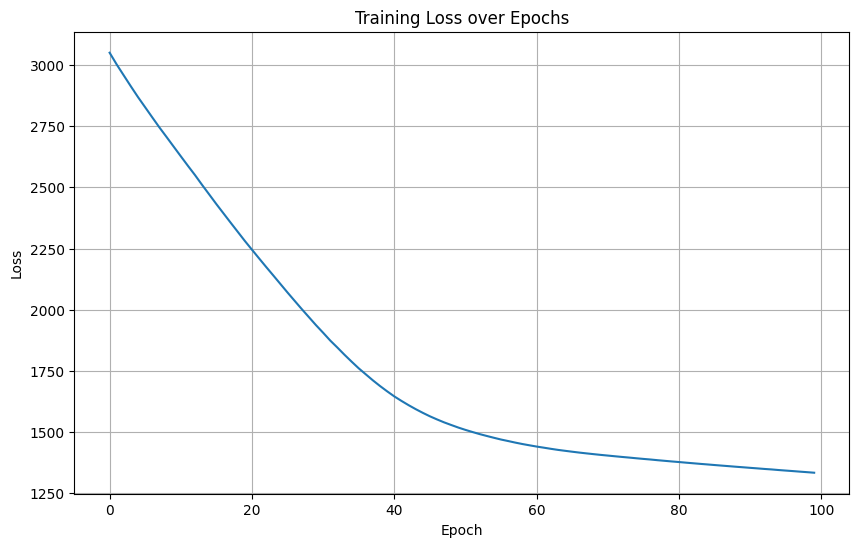

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_vals)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()


In [50]:
B_true

array([[0., 0., 0.],
       [1., 0., 1.],
       [1., 0., 0.]])

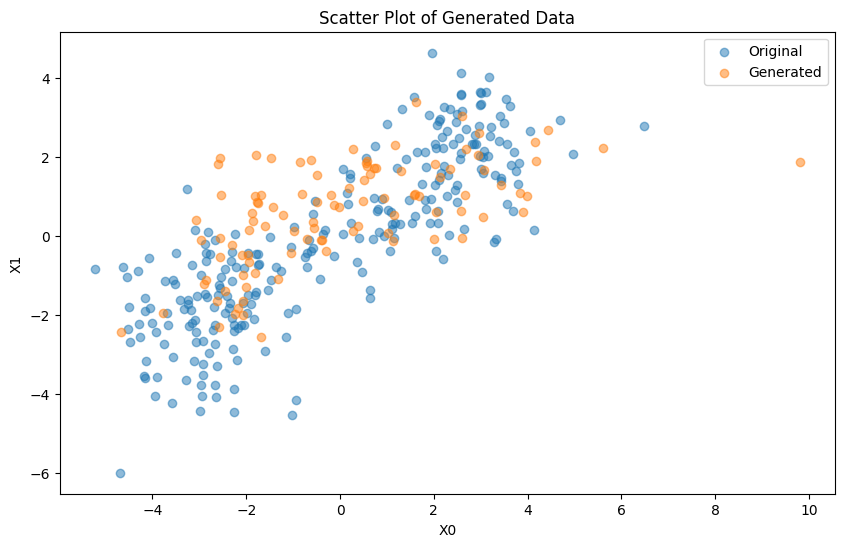

In [82]:
x_idx = 0
y_idx = 1

n = 100
xs = flow.sample(n)
X_gen = xs[-1].detach().cpu().numpy()

plt.figure(figsize=(10, 6))
plt.scatter(X[:, x_idx], X[:, y_idx], alpha=0.5, label='Original')
plt.scatter(X_gen[:, x_idx], X_gen[:, y_idx], alpha=0.5, label='Generated')
plt.xlabel(f'X{x_idx}')
plt.ylabel(f'X{y_idx}')
plt.title('Scatter Plot of Generated Data')
plt.legend()
plt.show()


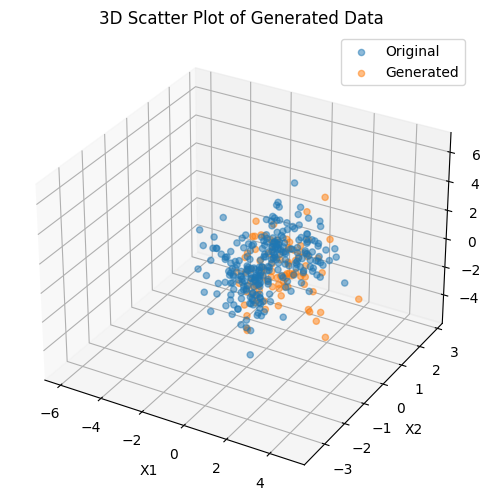

In [78]:
xy_idx = [1, 2]
z_idx = 0

xs = flow.sample(n)
X_gen = xs[-1].detach().cpu().numpy()


plt.figure(figsize=(10, 6))
ax = plt.axes(projection='3d')

# Plot 3D scatter
# Plot original data
ax.scatter3D(X[:, xy_idx[0]], X[:, xy_idx[1]], X[:, z_idx], alpha=0.5, label='Original')

# Plot generated data
ax.scatter3D(X_gen[:, xy_idx[0]], X_gen[:, xy_idx[1]], X_gen[:, z_idx], alpha=0.5, label='Generated')
ax.legend()

# Labels
ax.set_xlabel(f'X{xy_idx[0]}')
ax.set_ylabel(f'X{xy_idx[1]}') 
ax.set_zlabel(f'X{z_idx}')

plt.title('3D Scatter Plot of Generated Data')
plt.show()


## 3.2 因果グラフ未知のケース

In [75]:
n, d, s0, graph_type, linear, gam, lambda1, w_threshold = 256, 3, 3, 'ER', False, 3.0, 0.1, 0.3
batch_size, epochs, nh, scale_shift_base = 128, 100, 10, True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X, B_true, W, B_est, flow, loss_vals = train_pipeline_with_notears(n, d, s0, graph_type, linear, gam, lambda1, w_threshold, batch_size, epochs, nh, scale_shift_base, device)


100%|██████████| 100/100 [00:03<00:00, 29.38it/s]


In [76]:
B_true, B_est

(array([[0., 0., 0.],
        [1., 0., 0.],
        [1., 1., 0.]]),
 array([[0, 0, 0],
        [1, 0, 0],
        [1, 1, 0]], dtype=int32))

## 3.3 training_pipelineモジュールの動作確認

In [2]:
import os

os.chdir('/home/hashikami/projects/Diff')

In [57]:
# 初期化テスト

from carefl.experiments import training_pipeline
import importlib

importlib.reload(training_pipeline)

from carefl.experiments.training_pipeline import CareFLTrainingPipeline
import yaml
import argparse

with open('config/config.yaml', 'r') as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
    
def dict2namespace(config):
    namespace = argparse.Namespace()
    for key, value in config.items():
        if isinstance(value, dict):
            new_value = dict2namespace(value)
        else:
            new_value = value
        setattr(namespace, key, new_value)
    return namespace
    
config = dict2namespace(config_raw)
train_pipeline = CareFLTrainingPipeline(config)

In [49]:
# 各メソッドの動作確認

X = train_pipeline.simulate_sem()
X.shape, train_pipeline.B_true.shape, train_pipeline.W.shape

((256, 3), (3, 3), (3, 3))

In [22]:
dset = train_pipeline._get_datasets(X)

In [50]:
B_est = train_pipeline._notears_linear(X)
train_pipeline.B_true, B_est

(array([[0., 1., 0.],
        [0., 0., 0.],
        [1., 1., 0.]]),
 array([[0, 1, 0],
        [0, 0, 0],
        [1, 1, 0]], dtype=int32))

In [58]:
flow, loss_vals = train_pipeline._train()

100%|██████████| 200/200 [00:06<00:00, 29.31it/s]


In [59]:
train_pipeline.B_true

array([[0., 1., 0.],
       [0., 0., 0.],
       [1., 1., 0.]])

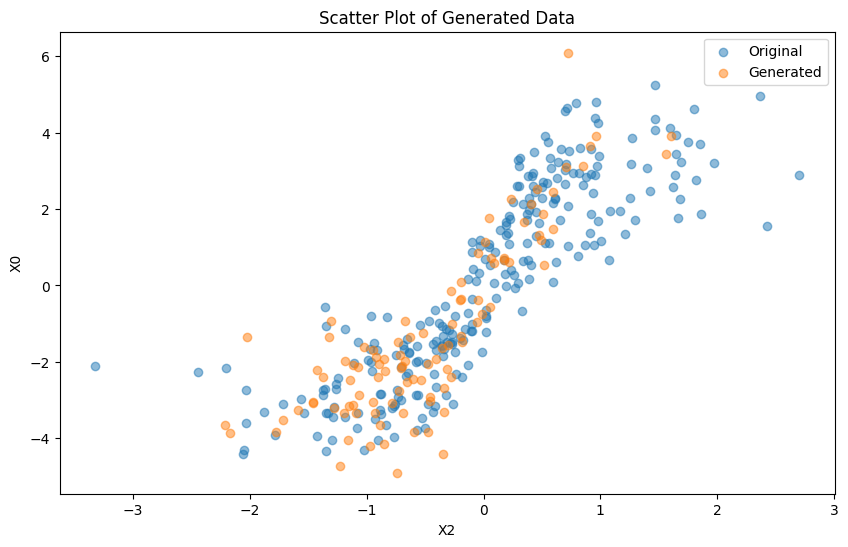

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import torch

x_idx = 2
y_idx = 0

n = 100
xs = flow.sample(n)
X_gen = xs[-1].detach().cpu().numpy()
X = train_pipeline.X

plt.figure(figsize=(10, 6))
plt.scatter(X[:, x_idx], X[:, y_idx], alpha=0.5, label='Original')
plt.scatter(X_gen[:, x_idx], X_gen[:, y_idx], alpha=0.5, label='Generated')
plt.xlabel(f'X{x_idx}')
plt.ylabel(f'X{y_idx}')
plt.title('Scatter Plot of Generated Data')
plt.legend()
plt.show()


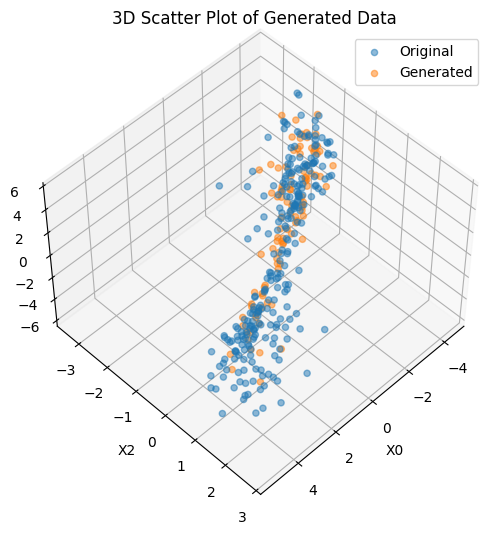

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import torch



xy_idx = [0, 2]
z_idx = 1

n = 100
xs = flow.sample(n)
X_gen = xs[-1].detach().cpu().numpy()
X = train_pipeline.X


plt.figure(figsize=(10, 6))
ax = plt.axes(projection='3d')

# Set viewing angle (elevation, azimuth)
ax.view_init(elev=50, azim=45)

# Plot 3D scatter
# Plot original data
ax.scatter3D(X[:, xy_idx[0]], X[:, xy_idx[1]], X[:, z_idx], alpha=0.5, label='Original')

# Plot generated data
ax.scatter3D(X_gen[:, xy_idx[0]], X_gen[:, xy_idx[1]], X_gen[:, z_idx], alpha=0.5, label='Generated')
ax.legend()

# Labels
ax.set_xlabel(f'X{xy_idx[0]}')
ax.set_ylabel(f'X{xy_idx[1]}') 
ax.set_zlabel(f'X{z_idx}')

plt.title('3D Scatter Plot of Generated Data')
plt.show()


In [62]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add original data scatter plot
fig.add_trace(go.Scatter3d(
    x=X[:, xy_idx[0]],
    y=X[:, xy_idx[1]], 
    z=X[:, z_idx],
    mode='markers',
    name='Original',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

# Add generated data scatter plot  
fig.add_trace(go.Scatter3d(
    x=X_gen[:, xy_idx[0]],
    y=X_gen[:, xy_idx[1]],
    z=X_gen[:, z_idx],
    mode='markers', 
    name='Generated',
    marker=dict(
        size=3,
        opacity=0.5
    )
))

# Update layout
fig.update_layout(
    title='3D Scatter Plot of Generated Data (Interactive)',
    scene = dict(
        xaxis_title=f'X{xy_idx[0]}',
        yaxis_title=f'X{xy_idx[1]}',
        zaxis_title=f'X{z_idx}'
    ),
    width=1000,
    height=700
)

#fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'Original',
              'type': 'scatter3d',
              'x': {'bdata': ('lhV2Tj1FA8BNpwWW9+Xyv97qRGgApw' ... 'as3iICwHafwka30Po/pH9+w0w9DsA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('wH0s4BQcyL8FoepdO5i4v+tVLm+uLN' ... 'TWEocDwN1d8x7yQ+8/RF5gLYQ04r8='),
                    'dtype': 'f8'},
              'z': {'bdata': ('GglR2C1YBEBvvenkSJ0MQMkA7qm9SQ' ... 'dBnOr4vzlHqC48xwDAO4fIvGsM9D8='),
                    'dtype': 'f8'}},
             {'marker': {'opacity': 0.5, 'size': 3},
              'mode': 'markers',
              'name': 'Generated',
              'type': 'scatter3d',
              'x': {'bdata': ('Q+ucP/0OJL/PPZM/Lv0lQNdaG0BWFh' ... 'BbRoPAe0TWv1utpD+/u2bAOUvKvw=='),
                    'dtype': 'f4'},
              'y': {'bdata': ('ukl2PnE70b4qGlY+5emBP7IPtT4iwt' ... '5BS6a/t9cpv+OXjD5d3Ly/i0lQvg=='),
                    'dtype': 'f4'},
              'z': {'bdata': ('0bgfwDG2pDwXxsu/2x9FwENywr9uym' ... 'DGjEJAxd4aQPNiiL/5WlNAEjwIQA=='),
                    'dtype': 'f4'}}],
    'layout': {'height': 700,
               'scene': {'xaxis': {'title': {'text': 'X0'}},
                         'yaxis': {'title': {'text': 'X2'}},
                         'zaxis': {'title': {'text': 'X1'}}},
               'template': '...',
               'title': {'text': '3D Scatter Plot of Generated Data (Interactive)'},
               'width': 1000}
})